# Experiment 9

## Aim

To implement the Backpropagation Algorithm using a Multilayer Perceptron (MLP) and analyze the learning process.

## Theory

Backpropagation is one of the most important algorithms in Deep Learning. It is used to train neural networks by minimizing the prediction error.

Working of Backpropagation:

1. Perform Forward Propagation.
2. Calculate the prediction error (Loss).
3. Compute gradients using the Chain Rule.
4. Update weights and biases.
5. Repeat until the loss becomes minimum.

Weight Update Formula:

Wnew = Wold − η × ∂L/∂W

where

η = Learning Rate
L = Loss Function

Backpropagation allows the network to learn from its mistakes by continuously adjusting the weights.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

print("Dataset Loaded Successfully")

print("Shape:", X.shape)

Dataset Loaded Successfully
Shape: (150, 4)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)

print("Training Samples:",len(X_train))

print("Testing Samples:",len(X_test))

Training Samples: 120
Testing Samples: 30


In [4]:
model = MLPClassifier(

    hidden_layer_sizes=(8,),

    activation="relu",

    solver="adam",

    learning_rate_init=0.01,

    max_iter=500,

    random_state=42

)

model.fit(X_train,y_train)

print("Training Completed Successfully")

Training Completed Successfully


In [5]:
y_pred = model.predict(X_test)

print("Predicted Output")

print(y_pred)

Predicted Output
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [6]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy =",accuracy)

Accuracy = 1.0


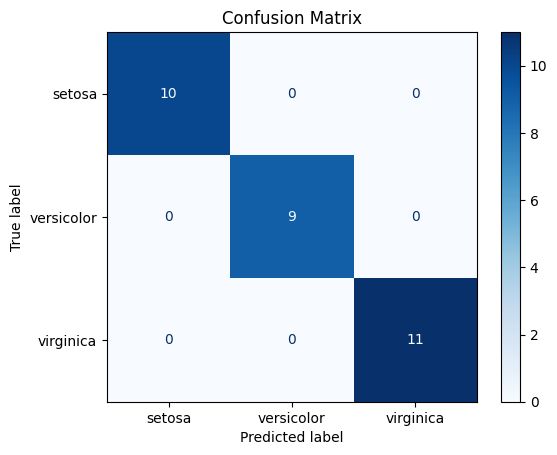

In [7]:
cm = confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=iris.target_names

)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

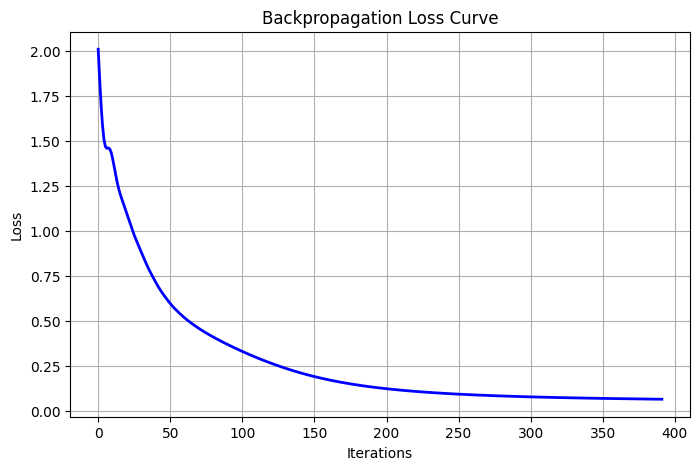

In [8]:
plt.figure(figsize=(8,5))

plt.plot(model.loss_curve_,
         color="blue",
         linewidth=2)

plt.title("Backpropagation Loss Curve")

plt.xlabel("Iterations")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

In [9]:
print("Weight Matrix")

print(model.coefs_)

Weight Matrix
[array([[ 2.51377361e-10,  7.44025486e-01,  6.67713103e-01,
         1.75526163e-01, -1.96782234e-09, -1.96581720e-09,
        -1.50777487e-01,  9.48664785e-01],
       [ 2.32762969e-10,  8.24067257e-01, -1.55393983e+00,
         4.30546485e-01,  2.13943014e-09,  1.20282707e-09,
        -9.72752993e-02,  1.74843654e-01],
       [-5.61673266e-10, -4.42403528e-01,  1.31494811e+00,
         8.36525623e-04, -1.29505056e-11,  6.79995069e-10,
        -8.31695536e-02, -5.62263589e-01],
       [-8.00121128e-11, -1.29148660e-01,  1.13805301e+00,
         2.74494349e-01, -3.21663588e-11, -4.75129490e-09,
        -3.06379559e-02, -1.48504756e+00]]), array([[ 3.10360060e-09,  2.37906710e-12,  2.21954180e-08],
       [ 9.96368675e-01, -2.63459582e-01, -7.05844722e-01],
       [-1.87234743e+00, -9.33565535e-02,  1.80860946e+00],
       [-1.01507374e-02,  5.74260174e-01, -1.30299544e-01],
       [ 1.26483614e-09,  2.37831650e-09,  2.39789829e-10],
       [ 8.92165684e-09, -8.21633044e-0

             Input Layer

          x₁   x₂   x₃   x₄

                 │

                 ▼

          Hidden Layer

         ○ ○ ○ ○ ○ ○ ○ ○

                 │

                 ▼

          Output Layer

           ○   ○   ○

                 │

          Predicted Output

                 │

             Calculate Loss

                 │

         Backpropagation

                 │

         Update Weights

                 │

          Repeat Training